## Imports

In [1]:
import os

In [2]:
from pathlib import Path

import pandas as pd

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_chroma import Chroma

from langchain_core.documents import Document

from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
)

from langchain_core.output_parsers import (
    StrOutputParser,
)

from langchain_core.prompts import (
    ChatPromptTemplate,
)

from langchain_groq import ChatGroq

from langchain_huggingface import (
    HuggingFaceEmbeddings,
)

from prompt_baker.optimizer import (
    PromptBakerOptimizer,
)

from prompt_baker.types import (
    ChatModelSpec,
    OptimizerConfig,
)

## KNOWLEDGE BASE

In [3]:
knowledge_base_text = """
DOG: Labrador Retriever
Color: Golden
Traits: Friendly, intelligent, family dog.

DOG: German Shepherd
Color: Black and tan
Traits: Loyal, protective, police dog.

DOG: Siberian Husky
Color: Grey and white
Traits: Energetic, wolf-like appearance.

DOG: Poodle
Color: White
Traits: Smart, curly fur.

DOG: Beagle
Color: Brown, black, white
Traits: Small hunting dog.

CAT: Persian Cat
Color: White
Traits: Long fur, calm temperament.

CAT: Russian Blue
Color: Grey
Traits: Quiet, intelligent, short-haired.

CAT: Siamese Cat
Color: Cream with dark brown points
Traits: Vocal, social.

CAT: Bengal Cat
Color: Orange with black spots
Traits: Wild appearance, energetic.

CAT: Maine Coon
Color: Brown tabby
Traits: Large size, fluffy fur.
""".strip()

Path(
    "knowledge_base.txt"
).write_text(
    knowledge_base_text,
    encoding="utf-8",
)

734

## BENCHMARK DATASET

In [4]:
benchmark_df = pd.DataFrame(
    [
        {
            "input": "Which cat is grey in colour?",
            "target": "Russian Blue",
        },
        {
            "input": "Which dog is golden in colour?",
            "target": "Labrador Retriever",
        },
        {
            "input": "Which dog looks wolf-like?",
            "target": "Siberian Husky",
        },
        {
            "input": "Which cat is vocal?",
            "target": "Siamese Cat",
        },
        {
            "input": "Which dog has curly fur?",
            "target": "Poodle",
        },
        {
            "input": "Which cat has black spots?",
            "target": "Bengal Cat",
        },
    ]
)

benchmark_df.to_csv(
    "benchmark.csv",
    index=False,
)

## LOAD DOCUMENTS

In [5]:
raw_text = Path(
    "knowledge_base.txt"
).read_text()

documents = [
    Document(page_content=raw_text)
]

In [6]:
documents

[Document(metadata={}, page_content='DOG: Labrador Retriever\nColor: Golden\nTraits: Friendly, intelligent, family dog.\n\nDOG: German Shepherd\nColor: Black and tan\nTraits: Loyal, protective, police dog.\n\nDOG: Siberian Husky\nColor: Grey and white\nTraits: Energetic, wolf-like appearance.\n\nDOG: Poodle\nColor: White\nTraits: Smart, curly fur.\n\nDOG: Beagle\nColor: Brown, black, white\nTraits: Small hunting dog.\n\nCAT: Persian Cat\nColor: White\nTraits: Long fur, calm temperament.\n\nCAT: Russian Blue\nColor: Grey\nTraits: Quiet, intelligent, short-haired.\n\nCAT: Siamese Cat\nColor: Cream with dark brown points\nTraits: Vocal, social.\n\nCAT: Bengal Cat\nColor: Orange with black spots\nTraits: Wild appearance, energetic.\n\nCAT: Maine Coon\nColor: Brown tabby\nTraits: Large size, fluffy fur.')]

## SPLIT DOCUMENTS

In [7]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=20,
)

split_docs = splitter.split_documents(
    documents
)

## RAG COMPLETION FUNCTION

In [8]:
def make_rag_completion_fn(
    retriever,
):

    def rag_completion_fn(
        system_prompt: str,
        user_prompt: str,
    ) -> str:

        retrieved_docs = retriever.invoke(
            user_prompt
        )

        context = "\n\n".join(
            doc.page_content
            for doc in retrieved_docs
        )

        final_question = f"""
{system_prompt}

{user_prompt}
""".strip()

        response = rag_chain.invoke(
            {
                "context": context,
                "question": final_question,
            }
        )

        return response.strip()

    return rag_completion_fn

## EMBEDDING MODEL

In [9]:
embedding_model = HuggingFaceEmbeddings(
    model_name=(
        "sentence-transformers/all-MiniLM-L6-v2"
    )
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## VECTOR DATABASE

In [10]:
vectorstore = Chroma.from_documents(
    documents=split_docs,
    embedding=embedding_model,
    persist_directory="./catdog_chroma_db",
)

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 2}
)

## LLM

In [72]:
os.environ["GROQ_API_KEY"] = "your-groq-api-key"

In [46]:
llm_groq = ChatGroq(
    model="llama-3.3-70b-versatile"
)

## MULTI RETRIEVER STRATEGIES

In [47]:
retriever_strategies = {
    "similarity_k1": vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 1},
    ),

    "similarity_k2": vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 2},
    ),

    "similarity_k4": vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 4},
    ),

    "mmr_k2": vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={
            "k": 2,
            "fetch_k": 6,
        },
    ),

    "mmr_k4": vectorstore.as_retriever(
        search_type="mmr",
        search_kwargs={
            "k": 4,
            "fetch_k": 10,
        },
    ),
}

## RAG COMPLETION FUNCTION

In [48]:
def make_rag_completion_fn(
    retriever,
):

    def rag_completion_fn(
        system_prompt: str,
        user_prompt: str,
    ) -> str:

        retrieved_docs = retriever.invoke(
            user_prompt
        )

        context = "\n\n".join(
            doc.page_content
            for doc in retrieved_docs
        )

        final_question = f"""
{system_prompt}

{user_prompt}
""".strip()

        response = rag_chain.invoke(
            {
                "context": context,
                "question": final_question,
            }
        )

        return response.strip()

    return rag_completion_fn

## MODEL SPECS

#### FACTORY FUNCTION - `EACH RETRIEVAL STRATEGY BECOMES A MODEL(You can try with Chunking also the same)`

In [49]:
def make_rag_completion_fn(
    retriever,
):

    def rag_completion_fn(
        system_prompt: str,
        user_prompt: str,
    ) -> str:

        docs = retriever.invoke(
            user_prompt
        )

        context = "\n\n".join(
            doc.page_content
            for doc in docs
        )

        final_prompt = f"""
Context:
{context}

{system_prompt}

Question:
{user_prompt}
""".strip()

        response = llm_groq.invoke(
            final_prompt
        )

        return response.content.strip()

    return rag_completion_fn

In [50]:
model_specs = []

for strategy_name, retriever in (
    retriever_strategies.items()
):

    model_specs.append(
        ChatModelSpec(
            name=strategy_name,

            completion_fn=make_rag_completion_fn(
                retriever
            ),
        )
    )

In [51]:
model_specs

[ChatModelSpec(name='similarity_k1', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d1260>),
 ChatModelSpec(name='similarity_k2', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d0ea0>),
 ChatModelSpec(name='similarity_k4', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d1080>),
 ChatModelSpec(name='mmr_k2', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d1620>),
 ChatModelSpec(name='mmr_k4', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d13a0>)]

## PARAPHRASER COMPLETION

In [52]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage



def paraphraser__groq_completion_fn(prompt: str) -> str:
    llm_groq_paraphraser = ChatGroq(
        model="llama-3.3-70b-versatile"
    )
    response = llm_groq_paraphraser.invoke(
        [
            SystemMessage(
                content=(
                    "You are an expert prompt engineer specialized "
                    "in paraphrasing and optimizing prompts."
                )
            ),
            HumanMessage(content=prompt),
        ]
    )

    return response.content.strip()

## RAG CHAIN

In [53]:
rag_prompt = ChatPromptTemplate.from_template(
    """
Context:
{context}

Question:
{question}

Instructions:
- Answer ONLY using retrieved context
- Be concise
- Avoid hallucinations
"""
)

rag_chain = (
    rag_prompt
    | llm_groq
    | StrOutputParser()
)

## RAG COMPLETION FUNCTION

In [54]:
def rag_completion_fn(
    system_prompt: str,
    user_prompt: str,
) -> str:

    retrieved_docs = retriever.invoke(
        user_prompt
    )

    context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    final_question = f"""
{system_prompt}

{user_prompt}
""".strip()

    response = rag_chain.invoke(
        {
            "context": context,
            "question": final_question,
        }
    )

    return response.strip()

## LLM JUDGE : please write one function like this to get results. You can write any function.

In [55]:
def llm_judge_fn(
    expected_answer: str,
    predicted_answer: str,
    scale_max: float,
) -> float:

    judge_prompt = f"""
Expected Answer:
{expected_answer}

Predicted Answer:
{predicted_answer}

Score from 0 to {scale_max}.

Evaluation Criteria:
- factual correctness
- semantic similarity
- exactness

Return ONLY number.
""".strip()

    response = llm_groq.invoke(
        [
            SystemMessage(
                content="You are a strict evaluator."
            ),
            HumanMessage(
                content=judge_prompt
            ),
        ]
    )

    text = response.content.strip()

    try:
        return float(text)

    except:
        return 0.0

## MODEL SPECS

In [56]:
model_specs

[ChatModelSpec(name='similarity_k1', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d1260>),
 ChatModelSpec(name='similarity_k2', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d0ea0>),
 ChatModelSpec(name='similarity_k4', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d1080>),
 ChatModelSpec(name='mmr_k2', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d1620>),
 ChatModelSpec(name='mmr_k4', completion_fn=<function make_rag_completion_fn.<locals>.rag_completion_fn at 0x3688d13a0>)]

## SYSTEM PROMPTS

In [57]:
system_prompts = [
    "Answer only from retrieved context.",

    "You are a RAG QA assistant for cats and dogs.",

    "Use retrieved evidence before answering.",

    "Never hallucinate information.",

    "Provide concise factual answers.",
]

## USER PROMPTS

In [58]:
user_prompts = [
    "{input}",

    "Question:\n{input}",

    "Use context and answer:\n{input}",

    "Answer carefully:\n{input}",
]

## OPTIMIZER CONFIG

In [59]:
config = OptimizerConfig(
    task_type="generation",
    metric="llm_as_judge",

    population_size=4,
    generations=5,

    mutation_rate=0.7,
    crossover_rate=0.7,

    elite_size=2,

    random_seed=42,

    input_column="input",
    target_column="target",

    token_length_optimisation=True,
    token_penalty_weight=0.05,

    paraphrases_per_prompt=2,

    judge_scale_max=10.0,
)

## OPTIMIZER

In [60]:
optimizer = PromptBakerOptimizer(
    model_specs=model_specs,

    system_prompts=system_prompts,
    user_prompts=user_prompts,

    config=config,

    paraphrase_completion_fn=(
        paraphraser__groq_completion_fn
    ),

    judge_score_fn=llm_judge_fn,
    run_dir="logs_cat_dog_rag"
)

## RUN

In [61]:
best_candidate = optimizer.optimize(
    dataset_csv="benchmark.csv",
    verbose=True,
)

Baking process started ... 📄📄📄📄📄 ➜ 🥣 ➜ ♨️🔥🔥🔥



Generations:   0%|          | 0/5 [00:00<?, ?it/s]

Generation 1 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 2 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 3 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 4 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

Generation 5 candidates:   0%|          | 0/4 [00:00<?, ?it/s]

🍞 Prompt model combination baked(optimized) successfully ✨



# Visualise results

In [62]:
from prompt_baker.visualizer import plot_progress

In [63]:
plot_file = plot_progress('logs_cat_dog_rag')#(optimizer.logger.run_dir)
print(f"Progress plot: {plot_file}")

Progress plot: logs_cat_dog_rag/progress.png


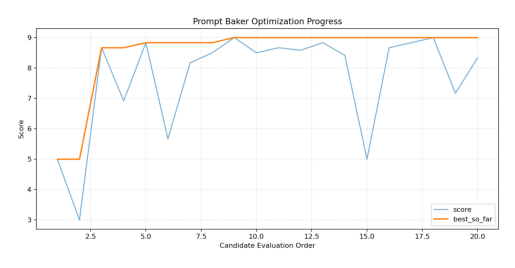

In [64]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('logs_cat_dog_rag/progress.png')
plt.imshow(img)
plt.axis('off') # Hide the X and Y axes
plt.show()

Once baking is done get the baked version of raw prompt. more time you keep baking with different parameters in population size, ... config params different results you will receive.
Meanwhile you also can print reports like below to see which prompt,model and parameter

In [65]:
from prompt_baker.visualizer import create_scores_csv

In [66]:
create_scores_csv('logs_cat_dog_rag/',"generated_report_cat_dog_rag.csv")

PosixPath('generated_report_cat_dog_rag.csv')

In [67]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [71]:
pd.read_csv("generated_report_cat_dog_rag.csv").head(7)

,timestamp,generation,candidate_idx,score,base_score,final_score,model_name,system_prompt,user_prompt,system_original_prompt,system_paraphrased_prompt,user_original_prompt,user_paraphrased_prompt
0,2026-05-11T15:07:56.480795+00:00,4,1,8.997537,9.000000,8.997537,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input}
1,2026-05-11T15:03:12.886140+00:00,2,0,8.997537,9.000000,8.997537,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input}
2,2026-05-11T15:07:25.355119+00:00,4,0,8.830871,8.833333,8.830871,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input}
3,2026-05-11T15:05:19.813997+00:00,3,0,8.830871,8.833333,8.830871,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input}
4,2026-05-11T15:01:09.428919+00:00,1,0,8.830871,8.833333,8.830871,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input}
5,2026-05-11T15:04:16.427766+00:00,2,2,8.664954,8.666667,8.664954,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,{input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},{input}\n\nOriginal prompt:\nQuestion:\n{input}
6,2026-05-11T15:06:53.940267+00:00,3,3,8.664204,8.666667,8.664204,mmr_k4,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input},Use retrieved evidence before answering.,Answer based on retrieved evidence.\n\nOriginal prompt:\nUse retrieved evidence before answering.,Question:\n{input},REWRITTEN PROMPT:\nPlease respond to the following question: {input}\n\nOriginal prompt:\nQuestion:\n{input}


# You can see now which things are causing improvement with minimum experementation(searching over all possible cases)